In [33]:
# Install required libraries
!pip install -q ydata_profiling
!pip install -q scikit-learn

ERROR: Ignored the following versions that require a different python version: 4.0.0 Requires-Python >=3.7,<3.11; 4.1.0 Requires-Python >=3.7,<3.12; 4.1.1 Requires-Python >=3.7,<3.12; 4.1.2 Requires-Python >=3.7,<3.12; 4.10.0 Requires-Python >=3.7,<3.13; 4.11.0 Requires-Python >=3.7,<3.13; 4.12.0 Requires-Python >=3.7,<3.13; 4.12.1 Requires-Python >=3.7,<3.13; 4.12.2 Requires-Python >=3.7,<3.13; 4.13.0 Requires-Python >=3.7,<3.13; 4.14.0 Requires-Python >=3.7,<3.13; 4.15.0 Requires-Python >=3.7,<3.13; 4.15.1 Requires-Python >=3.7,<3.13; 4.16.0 Requires-Python >=3.7,<3.13; 4.16.1 Requires-Python >=3.7,<3.13; 4.17.0 Requires-Python >=3.7,<3.14; 4.18.0 Requires-Python >=3.10,<3.14; 4.18.1 Requires-Python >=3.10,<3.14; 4.18.4 Requires-Python >=3.10,<3.14; 4.2.0 Requires-Python >=3.7,<3.12; 4.3.0 Requires-Python >=3.7,<3.12; 4.3.1 Requires-Python >=3.7,<3.12; 4.3.2 Requires-Python >=3.7,<3.12; 4.4.0 Requires-Python >=3.7,<3.12; 4.5.0 Requires-Python >=3.7,<3.12; 4.5.1 Requires-Python >=3.7,

In [3]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [7]:
df.drop(['deck'],axis=1,inplace=True)
df.drop(['class'],axis=1,inplace=True)
df.drop(['embark_town'],axis=1,inplace=True)
df.drop(['adult_male'],axis=1,inplace=True)
df.drop(['alive'],axis=1,inplace=True)
df.drop(['alone'],axis=1,inplace=True)
df['age']=df['age'].fillna(df['age'].median())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
df.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
who         0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    str    
 8   who       891 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


In [9]:
df.duplicated().sum()

np.int64(116)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  775 non-null    int64  
 1   pclass    775 non-null    int64  
 2   sex       775 non-null    str    
 3   age       775 non-null    float64
 4   sibsp     775 non-null    int64  
 5   parch     775 non-null    int64  
 6   fare      775 non-null    float64
 7   embarked  775 non-null    str    
 8   who       775 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 60.5 KB


array([[<Axes: title={'center': 'survived'}>,
        <Axes: title={'center': 'pclass'}>],
       [<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'sibsp'}>],
       [<Axes: title={'center': 'parch'}>,
        <Axes: title={'center': 'fare'}>]], dtype=object)

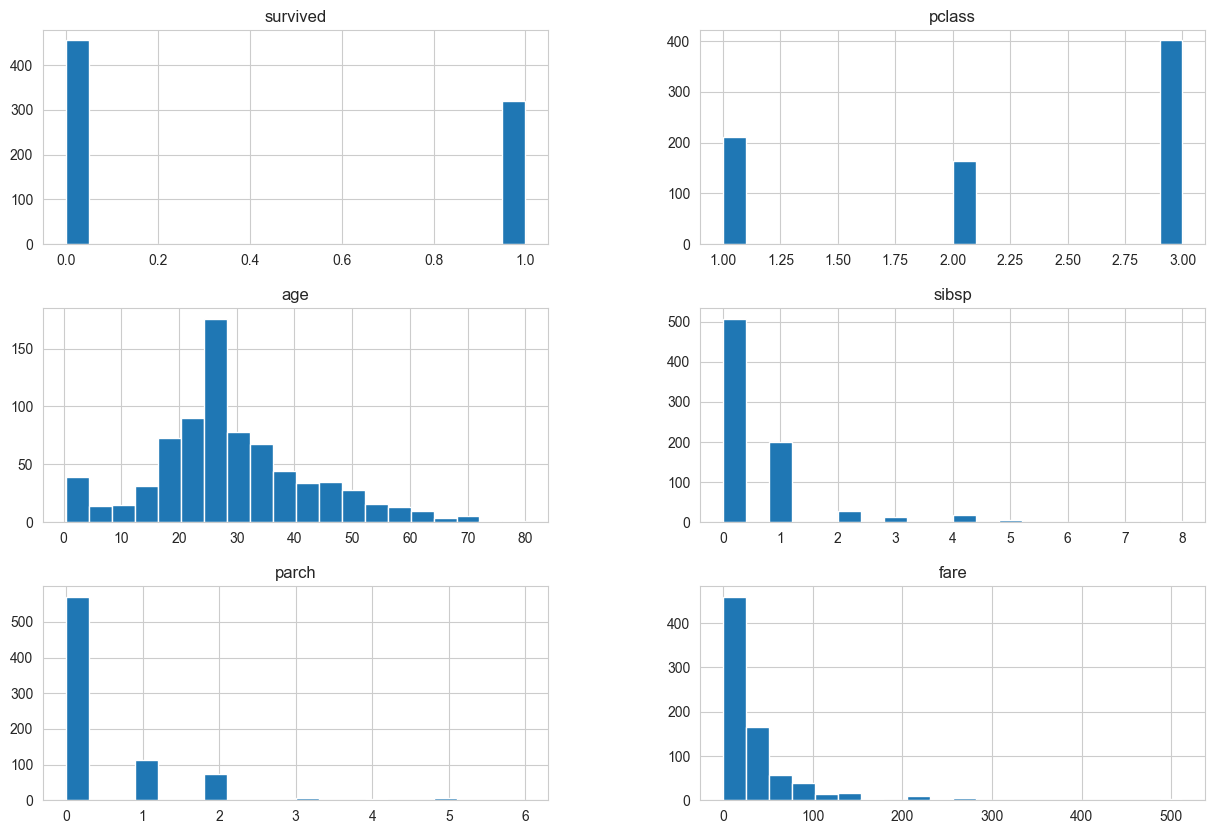

In [13]:
df.hist(bins=20, figsize=(15, 10))

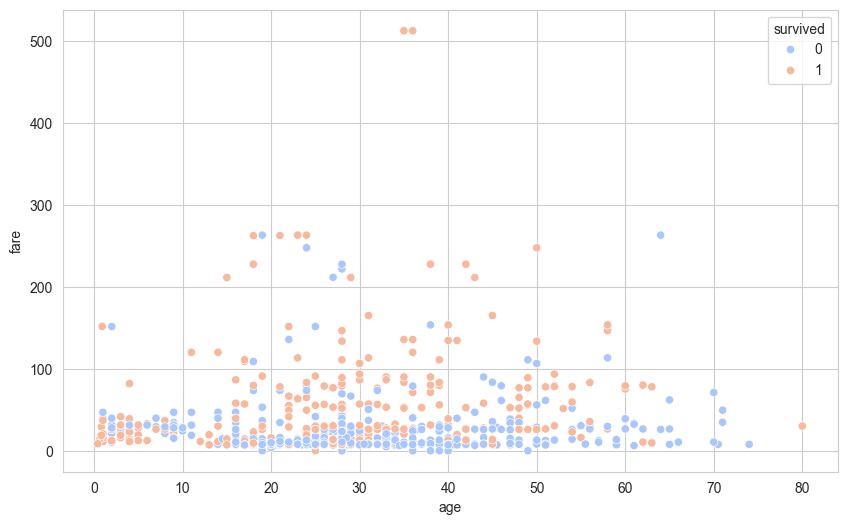

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='fare', hue='survived', palette='coolwarm')

plt.show()

<Axes: ylabel='fare'>

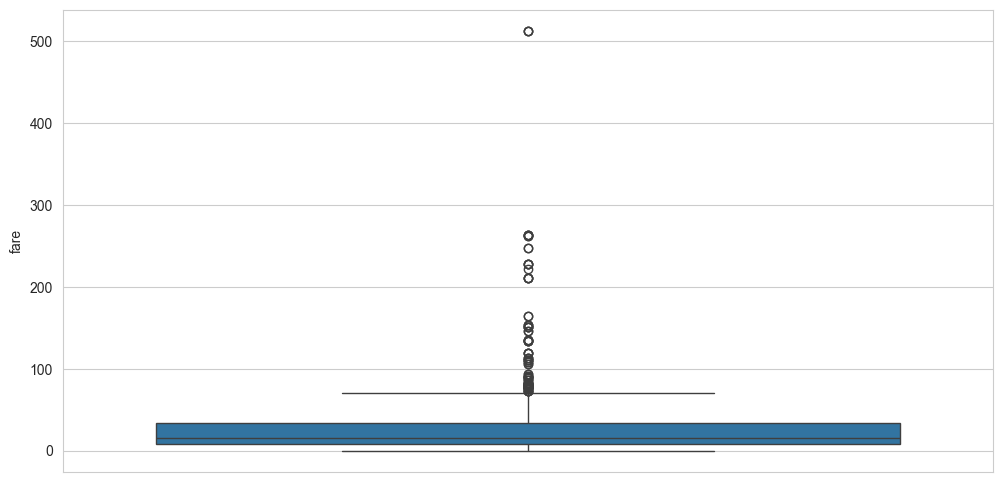

In [15]:
sns.boxplot(df['fare'])

In [16]:
Q1=df['fare'].quantile(0.25)
Q3=df['fare'].quantile(0.75)
IQR=Q3-Q1
print(IQR)

26.147900000000003


In [17]:
from numpy._core.defchararray import upper
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df['Fare'] = np.where(df['fare'] > upper, upper, df['fare'])
df['Fare'] = np.where(df['fare'] < lower, lower, df['fare'])
df=df[(df['fare']>=lower) & (df['fare']<=upper) ]

<Axes: ylabel='fare'>

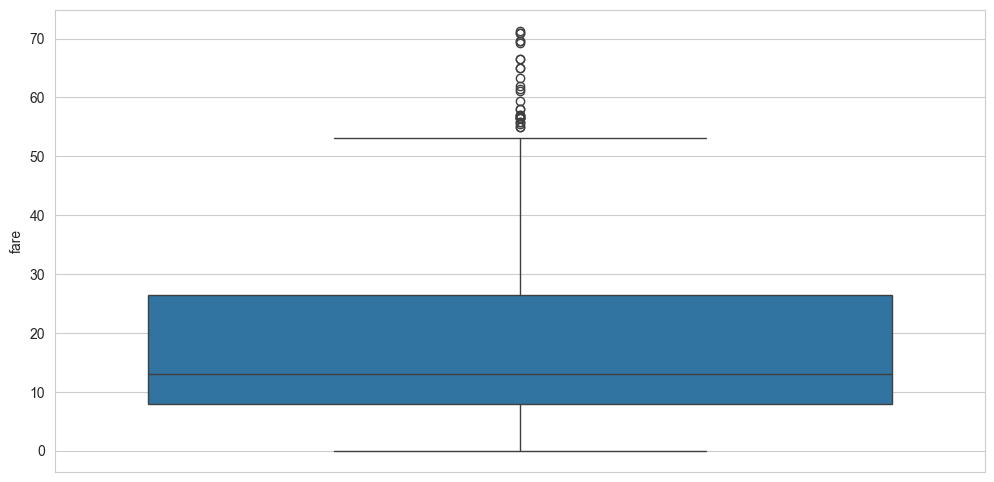

In [18]:
sns.boxplot(df['fare'])

In [19]:
df.drop(['fare'],axis=1,inplace=True)
df.rename(columns={'Fare':'fare'},inplace=True)
df.head()


,survived,pclass,sex,age,sibsp,parch,embarked,who,fare
0,0,3,male,22.0,1,0,S,man,7.2500
1,1,1,female,38.0,1,0,C,woman,71.2833
2,1,3,female,26.0,0,0,S,woman,7.9250
3,1,1,female,35.0,1,0,S,woman,53.1000
4,0,3,male,35.0,0,0,S,man,8.0500


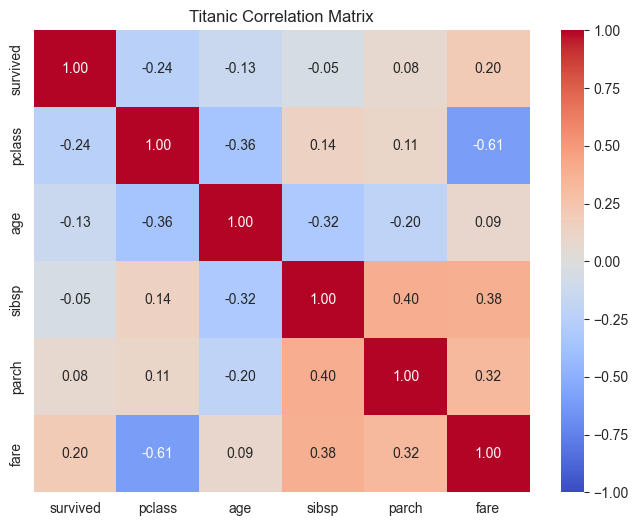

In [20]:
titanic_corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(titanic_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Titanic Correlation Matrix')
plt.show()

In [21]:
encoder=LabelEncoder()

df['sex']=encoder.fit_transform(df['sex'])
df['embarked']=encoder.fit_transform(df['embarked'])
df['who']=encoder.fit_transform(df['who'])
df.head(10)

,survived,pclass,sex,age,sibsp,parch,embarked,who,fare
0,0,3,1,22.0,1,0,2,1,7.2500
1,1,1,0,38.0,1,0,0,2,71.2833
2,1,3,0,26.0,0,0,2,2,7.9250
3,1,1,0,35.0,1,0,2,2,53.1000
4,0,3,1,35.0,0,0,2,1,8.0500
5,0,3,1,28.0,0,0,1,1,8.4583
6,0,1,1,54.0,0,0,2,1,51.8625
7,0,3,1,2.0,3,1,2,0,21.0750
8,1,3,0,27.0,0,2,2,2,11.1333
9,1,2,0,14.0,1,0,0,0,30.0708


In [25]:
x=df.drop(['survived','fare'],axis=1)
y=df['survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ['age', 'fare', 'pclass', 'sibsp', 'parch']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import pandas as pd
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
print(df_pca.head())

        PC1       PC2
0 -0.433640  1.155950
1  2.109741 -3.100728
2 -1.038986  0.763458
3  1.472350 -2.456020
4 -1.183801  0.412201


In [43]:
model1=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
model1.fit(x_train,y_train)
pred1=model1.predict(x_test)
accuracy1=accuracy_score(y_test,pred1)
print(accuracy*100,"%")

74.07407407407408 %


In [44]:
model2=LogisticRegression(max_iter=1000,random_state=42)
model2.fit(x_train,y_train)
pred2=model2.predict(x_test)
accuracy2=accuracy_score(y_test,pred2)
print(accuracy*100,"%")

74.07407407407408 %


In [45]:
model3=DecisionTreeClassifier(max_depth=100)
model3.fit(x_train,y_train)
pred3=model3.predict(x_test)
accuracy3=accuracy_score(y_test,pred3)
print(accuracy*100,"%")

74.07407407407408 %


C:\Users\dell\AppData\Local\Temp\ipykernel_4184\499395355.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_names, y=accuracies, palette='magma')


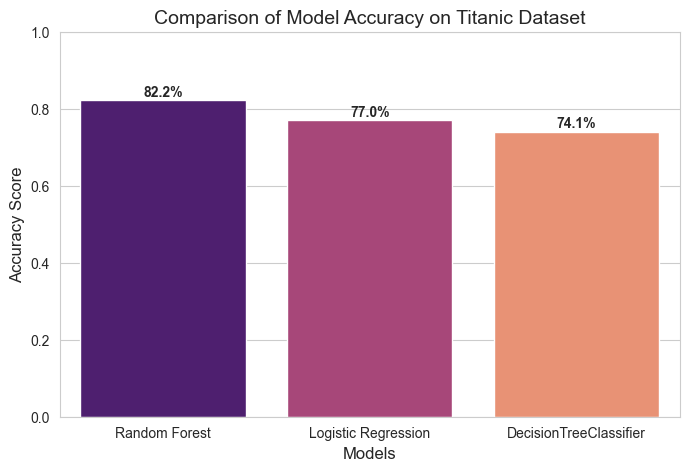

In [47]:

import matplotlib.pyplot as plt
import seaborn as sns

models_names = ['Random Forest', 'Logistic Regression', 'DecisionTreeClassifier']
accuracies = [accuracy1, accuracy2, accuracy3]  
plt.figure(figsize=(8, 5))
sns.barplot(x=models_names, y=accuracies, palette='magma')

plt.title('Comparison of Model Accuracy on Titanic Dataset', fontsize=14)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.0) 
for i, val in enumerate(accuracies):
    plt.text(i, val + 0.01, f"{val*100:.1f}%", ha='center', fontweight='bold')

plt.show()